<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/DLWEEK1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
def step (x) :
  return 1 if x>= 0 else 0
class Perceptron:
  def __init__(self,bias,weights):
    self.bias = bias
    self.weights = weights

  def predict(self,inputs):
    total = np.dot(self.weights , inputs) + self.bias
    return step(total)
weights = np.array([1,1])
bias = -1.5
and_gate = Perceptron(bias,weights)

print("AND GATE:")
for x in([0,0],[0,1],[1,0],[1,1]):
  print(x,and_gate.predict(x))





AND GATE:
[0, 0] 0
[0, 1] 0
[1, 0] 0
[1, 1] 1


In [ ]:
import numpy as np
def step (x) :
  return 1 if x>= 0 else 0
class Perceptron:
  def __init__(self,bias,weights):
    self.bias = bias
    self.weights = weights

  def predict(self,inputs):
    total = np.dot(self.weights , inputs) + self.bias
    return step(total)
weights = np.array([1,1])
bias = -1.5
or_gate = Perceptron(bias,weights)

print("OR GATE:")
for x in([0,0],[0,1],[1,0],[1,1]):
  print(x,or_gate.predict(x))

OR GATE:
[0, 0] 0
[0, 1] 0
[1, 0] 0
[1, 1] 1


In [ ]:
def AND(x1, x2):
    w1 = 1
    w2 = 1
    bias = -1.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def NAND(x1, x2):
    w1 = -1
    w2 = -1
    bias = 1.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def OR(x1, x2):
    w1 = 1
    w2 = 1
    bias = -0.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def XOR(x1, x2):
    a = OR(x1, x2)
    b = NAND(x1, x2)
    output =  AND(a, b)
    return output

for x1, x2 in ([0,0], [0,1], [1,0], [1,1]):
    print(XOR(x1,x2))



0
1
1
0


In [ ]:
def AND(x1, x2):
    w1 = 1
    w2 = 1
    bias = -1.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def NAND(x1, x2):
    w1 = -1
    w2 = -1
    bias = 1.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def OR(x1, x2):
    w1 = 1
    w2 = 1
    bias = -0.5
    activation = w1*x1 + w2*x2 + bias
    return 1 if activation > 0 else 0

def XOR(x1, x2):
    a = OR(x1, x2)
    b = NAND(x1, x2)
    output = AND(a,b)
    return output

def NOT(output):
  if output == 1:
    return 0
  else:
    return 1



for x1,x2 in ([0,0], [0,1], [1,0], [1,1]):
    print( NOT(XOR(x1,x2)))

1
0
0
1


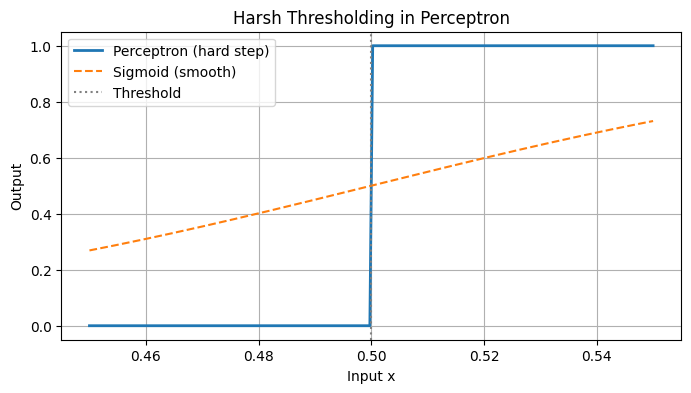

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


x = np.linspace(0.45, 0.55, 200)


w = 1.0
b = -0.5


perceptron_output = np.where(w * x + b >= 0, 1, 0)


sigmoid_output = 1 / (1 + np.exp(-(w * x + b) * 20))


plt.figure(figsize=(8, 4))
plt.plot(x, perceptron_output, label="Perceptron (hard step)", linewidth=2)
plt.plot(x, sigmoid_output, label="Sigmoid (smooth)", linestyle="--")
plt.axvline(0.5, color="gray", linestyle=":", label="Threshold")
plt.xlabel("Input x")
plt.ylabel("Output")
plt.title("Harsh Thresholding in Perceptron")
plt.legend()
plt.grid(True)
plt.show()


In [1]:
# ============================================================
# Perceptron Learning Algorithm – Movie Preference Prediction
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Create and Save Dataset (CSV)
# ------------------------------------------------------------
data = {
    'f1': [1, 1, 0, 0, 0, 1, 0, 1],   # Matt Damon
    'f2': [1, 0, 1, 0, 0, 0, 1, 1],   # Thriller
    'f3': [0, 0, 1, 1, 0, 1, 0, 1],   # Christopher Nolan
    'f4': [0.85, 0.60, 0.90, 0.75, 0.40, 0.30, 0.45, 0.95],  # IMDb rating
    'y' : [1, 1, 1, 1, 0, 0, 0, 1]    # Like (1) / Dislike (0)
}

df = pd.DataFrame(data)
df.to_csv("movies.csv", index=False)

print("Dataset created:\n")
print(df)

# ------------------------------------------------------------
# 2. Load Dataset
# ------------------------------------------------------------
data = pd.read_csv("movies.csv")

X = data[['f1', 'f2', 'f3', 'f4']].values
y = data['y'].values

# ------------------------------------------------------------
# 3. Step Activation Function
# ------------------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# ------------------------------------------------------------
# i) MP Perceptron (No weights, No bias)
# ------------------------------------------------------------
print("\n==============================")
print("MP PERCEPTRON (No weights, No bias)")
print("==============================")

def mp_perceptron(x):
    return step(np.sum(x))

for i in range(len(X)):
    pred = mp_perceptron(X[i])
    print(f"Input: {X[i]}  True: {y[i]}  Predicted: {pred}")

# ------------------------------------------------------------
# ii) Perceptron with Weights ONLY
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS ONLY")
print("==============================")

def train_perceptron_weights_only(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i])
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w

w_no_bias = train_perceptron_weights_only(X, y)
print("Final Weights (No Bias):", w_no_bias)

# ------------------------------------------------------------
# iii) Perceptron with Weights AND Bias
# ------------------------------------------------------------
print("\n==============================")
print("PERCEPTRON WITH WEIGHTS AND BIAS")
print("==============================")

def train_perceptron(X, y, lr=0.1, epochs=20):
    w = np.zeros(X.shape[1])
    b = 0

    for epoch in range(epochs):
        errors = 0
        for i in range(len(X)):
            z = np.dot(w, X[i]) + b
            y_pred = step(z)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        print(f"Epoch {epoch+1} | Errors: {errors}")
        if errors == 0:
            break
    return w, b

w, b = train_perceptron(X, y)
print("Final Weights:", w)
print("Final Bias:", b)

# ------------------------------------------------------------
# 4. Test with a Sample Movie
# ------------------------------------------------------------
print("\n==============================")
print("TESTING WITH A SAMPLE MOVIE")
print("==============================")

# Sample Movie:
# Matt Damon = 1, Thriller = 1, Nolan = 0, IMDb = 0.80
test_movie = np.array([1, 1, 0, 0.80])

mp_result = mp_perceptron(test_movie)
no_bias_result = step(np.dot(w_no_bias, test_movie))
bias_result = step(np.dot(w, test_movie) + b)

print("Test Movie Features:", test_movie)
print("MP Perceptron Prediction:", mp_result)
print("Perceptron (Weights Only) Prediction:", no_bias_result)
print("Perceptron (Weights + Bias) Prediction:", bias_result)

# ------------------------------------------------------------
# 5. Conclusion
# ------------------------------------------------------------
print("\n==============================")
print("OBSERVATIONS")
print("==============================")
print("MP Perceptron: No learning, poor classification")
print("Weights Only: Learns slowly, limited decision boundary")
print("Weights + Bias: Fast convergence and accurate prediction")


Dataset created:

   f1  f2  f3    f4  y
0   1   1   0  0.85  1
1   1   0   0  0.60  1
2   0   1   1  0.90  1
3   0   0   1  0.75  1
4   0   0   0  0.40  0
5   1   0   1  0.30  0
6   0   1   0  0.45  0
7   1   1   1  0.95  1

MP PERCEPTRON (No weights, No bias)
Input: [1.   1.   0.   0.85]  True: 1  Predicted: 1
Input: [1.  0.  0.  0.6]  True: 1  Predicted: 1
Input: [0.  1.  1.  0.9]  True: 1  Predicted: 1
Input: [0.   0.   1.   0.75]  True: 1  Predicted: 1
Input: [0.  0.  0.  0.4]  True: 0  Predicted: 1
Input: [1.  0.  1.  0.3]  True: 0  Predicted: 1
Input: [0.   1.   0.   0.45]  True: 0  Predicted: 1
Input: [1.   1.   1.   0.95]  True: 1  Predicted: 1

PERCEPTRON WITH WEIGHTS ONLY
Epoch 1 | Errors: 2
Epoch 2 | Errors: 4
Epoch 3 | Errors: 4
Epoch 4 | Errors: 4
Epoch 5 | Errors: 3
Epoch 6 | Errors: 4
Epoch 7 | Errors: 3
Epoch 8 | Errors: 4
Epoch 9 | Errors: 3
Epoch 10 | Errors: 4
Epoch 11 | Errors: 3
Epoch 12 | Errors: 4
Epoch 13 | Errors: 3
Epoch 14 | Errors: 4
Epoch 15 | Errors: 3
Ep

In [2]:
import numpy as np
from itertools import product

# --------------------------------------------------
# Step activation
# --------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# --------------------------------------------------
# Train perceptron
# --------------------------------------------------
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged

# --------------------------------------------------
# Inputs for 2-bit Boolean functions
# --------------------------------------------------
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# --------------------------------------------------
# Generate all Boolean functions
# --------------------------------------------------
boolean_functions = list(product([0, 1], repeat=4))

linearly_separable = 0
not_separable = 0
failed_functions = []

for idx, func in enumerate(boolean_functions):
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=2):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)

print("\nNon-linearly separable functions (truth tables):")
for f in failed_functions:
    print(f)


Total Boolean functions (n=2): 16
Linearly separable: 14
Not linearly separable: 2

Non-linearly separable functions (truth tables):
(0, 1, 1, 0)
(1, 0, 0, 1)


In [3]:
import numpy as np
from itertools import product

# --------------------------------------------------
# Step activation
# --------------------------------------------------
def step(z):
    return 1 if z >= 0 else 0

# --------------------------------------------------
# Train perceptron
# --------------------------------------------------
def train_perceptron(X, y, lr=0.1, epochs=50):
    w = np.zeros(X.shape[1])
    b = 0

    for _ in range(epochs):
        errors = 0
        for i in range(len(X)):
            y_pred = step(np.dot(w, X[i]) + b)
            error = y[i] - y_pred
            w += lr * error * X[i]
            b += lr * error
            errors += abs(error)
        if errors == 0:
            return True  # converged
    return False  # not converged

# --------------------------------------------------
# Inputs for 3-bit Boolean functions
# --------------------------------------------------
X = np.array(list(product([0, 1], repeat=3)))
# X has 8 rows now

# --------------------------------------------------
# Generate all Boolean functions (3 inputs → 8 outputs)
# --------------------------------------------------
boolean_functions = list(product([0, 1], repeat=8))

linearly_separable = 0
not_separable = 0
failed_functions = []

for func in boolean_functions:
    y = np.array(func)
    converged = train_perceptron(X, y)

    if converged:
        linearly_separable += 1
    else:
        not_separable += 1
        failed_functions.append(func)

# --------------------------------------------------
# Results
# --------------------------------------------------
print("Total Boolean functions (n=3):", len(boolean_functions))
print("Linearly separable:", linearly_separable)
print("Not linearly separable:", not_separable)


Total Boolean functions (n=3): 256
Linearly separable: 104
Not linearly separable: 152
